In [1]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import confusion_matrix


### Training Data Reading and Map generation

#### Checking if data has null to clean

In [6]:
df_test_btrain = pd.read_csv("OCR Neural Network/Datasets/emnist-balanced-train.csv")
df_test_btrain.isna().any().sum()

0

In [7]:
df_test_btrain.shape

(112799, 785)

While the train dataset is actually 112800 by 785 (1 label + 784 pix (28*28 px img)), pd.read_csv takes the first row of csv as columns. In the model scripts we will fix this by using a csv reader instead

In [8]:
df_test_btest = pd.read_csv("OCR Neural Network/Datasets/emnist-balanced-test.csv")
df_test_btest.isna().any().sum()

0

In [10]:
df_test_btest.shape 

(18799, 785)

While the test dataset is actually 18800 by 785 (1 label + 784 pix (28*28 px img)), pd.read_csv takes the first row of csv as columns. In the model scripts we will fix this by using a csv reader instead

#### Creating mapping for class to char

In [11]:
maps = open("OCR Neural Network/Datasets/emnist-balanced-mapping.txt",'r')
maps = {int(i):chr(int(j)) for i,j in [line.split() for line in maps.readlines()]}

#### Data Distribution

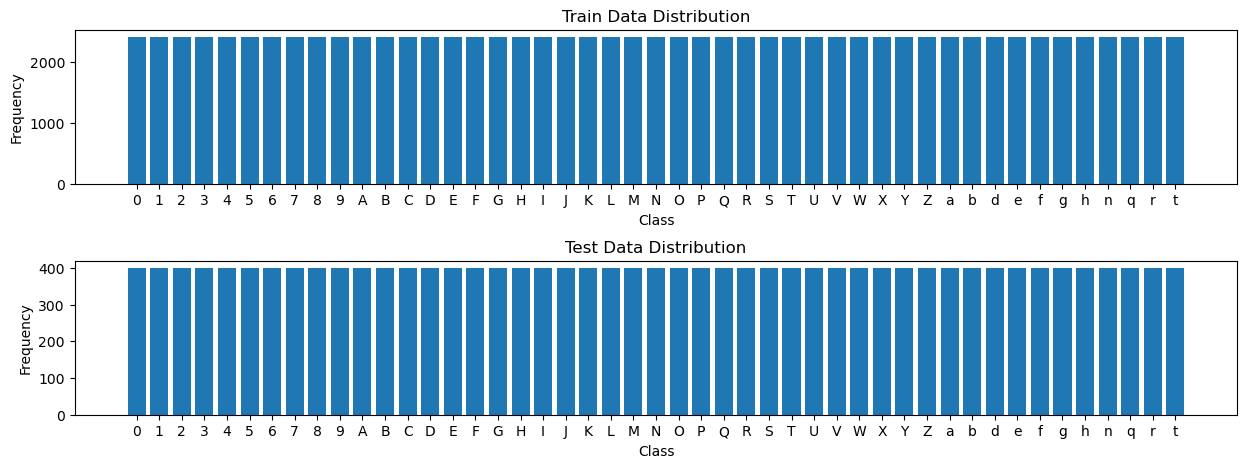

In [12]:
train_df_distribution = df_test_btrain.iloc[:,0].value_counts().sort_index()
test_df_distribution = df_test_btest.iloc[:,0].value_counts().sort_index()

train_df_distribution.index = train_df_distribution.index.map(maps)
test_df_distribution.index = test_df_distribution.index.map(maps)

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15,5))

ax1.bar(train_df_distribution.index, train_df_distribution.values)
ax1.set_title("Train Data Distribution")
ax1.set_xlabel("Class")
ax1.set_ylabel("Frequency")
ax2.bar(test_df_distribution.index, test_df_distribution.values)
ax2.set_title("Test Data Distribution")
ax2.set_xlabel("Class")
ax2.set_ylabel("Frequency")
plt.subplots_adjust(hspace=0.5)
plt.show()


#### Conclusion
- The data is pre cleaned as it was created by the NIST (National Institue of Standards and Technology, USA) and as such contains no null values or missing data
- Since we used the balanced dataset we can assume that the data is not skewed to any specific characters
- There are also some small letters dropped since the capital and the lowercase are similar (c, i, j, k, l, m, o, p, s, u, v, w, x, y, z) = (C, I, J, K,L ,M, O, P, S, U, V, W, X, Y, Z)
- Also we can deduce that the following steps with using the modeels and such will lead to errors in classifiying as (0 = O = o = D = Q) (1 = L = l = I) and a few other characters that look similar